# データ取得

In [2]:

import os
import json


base_path = "C:/Users/tenma/Desktop/KeioSchool/InteractiveSmartHome/InteractiveSmartHome/"
# base_path = "C:/Users/Tenma/Desktop/Keio/InteractiveSmartHome/InteractiveSmartHome"
# ================================　デバイスリスト　　================================
device_list_path = base_path + "InteractiveSmartHome/Assets/EXPERIMENT/device_list.json"


with open(device_list_path, "r", encoding="utf-8") as f:
    all_device_lists = json.load(f)
    

# ================================　タスクセット　　================================

# ディレクトリパス
task_sets_path = base_path + "InteractiveSmartHome/Assets/EXPERIMENT/ArrangeData"

# 対象ファイル
file_names = ["PreTaskArrangementA.json", "PreTaskArrangementB.json", 
              "PreTaskArrangementC.json", "PreTaskArrangementD.json"]

# すべてのタスクを格納するリスト
all_task_sets = []

# 各ファイルを読み込んで統合
for file_name in file_names:
    file_path = os.path.join(task_sets_path, file_name)
    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)
        all_task_sets.extend(data)  # 各ファイルがリスト形式であることを前提

# 確認（最初の1件だけ表示）
print(all_task_sets[0])

task_id_to_info = {}

for task in all_task_sets:
    task_id_to_info[task["device_arrange_id"]] = {
        "name": task["device_arrange_name"],
        "devices": task["devices"]
    }





# ================================　処理結果　　================================

import os
import json
from collections import defaultdict

# フォルダパス
result_dir = base_path + "/LLMServer/ExperimentData/RESULTS/SystemEvaluation"

# 除外する task_id のリスト（必要に応じて追加）
exclude_task_ids = {
    "b0e9f035-c92f-4dc6-bd0a-a10b2941f902"  # ← 外れ値
    # 他にも追加可能: "another-task-id", ...
}

# 結果を格納するネスト辞書
evaluation_results = defaultdict(dict)

# ファイル読み込みループ
for filename in os.listdir(result_dir):
    if filename.endswith(".json"):
        filepath = os.path.join(result_dir, filename)
        # ファイル名から model名 と 評価方式を抽出
        parts = filename.replace("SystemEvaluation_", "").replace(".json", "").split("_")
        model = parts[0]
        eval_type = parts[1] if len(parts) > 1 else "unknown"

        # JSONロード＋task_id除外
        with open(filepath, "r", encoding="utf-8") as f:
            data = json.load(f)

            # データがリスト形式なら除外フィルターをかける
            if isinstance(data, list):
                filtered_data = [entry for entry in data if entry.get("task_id") not in exclude_task_ids]
                evaluation_results[model][eval_type] = filtered_data
            else:
                evaluation_results[model][eval_type] = data  # 念のため辞書型も対応

# 利用例
print(evaluation_results["gpt-4o"]["pointing"][0])  # 最初のタスクの出力を確認



{'device_arrange_id': '2369c5c0-c4bb-4308-a9cd-05a64a69f91a', 'device_arrange_name': '手前三つ青奥三つ赤', 'device_arrange_type': [], 'devices': [{'deviceName': 'Ceiling Light 6', 'colorName': 'Blue', 'deviceId': '58126407-cde0-4d62-a13d-1a24bf8ea5f3'}, {'deviceName': 'Ceiling Light 2', 'colorName': 'Red', 'deviceId': '781e6091-cec9-4c26-9f3e-4d48d6d7570a'}, {'deviceName': 'Ceiling Light 4', 'colorName': 'Red', 'deviceId': '6ac4ec9f-0326-4619-b79a-ecbbe5459d23'}, {'deviceName': 'Ceiling Light 3', 'colorName': 'Red', 'deviceId': '6f1c35e2-1ca1-4f43-93cf-755d9479025b'}, {'deviceName': 'Ceiling Light 8', 'colorName': 'Blue', 'deviceId': '74a6f0f8-be5d-479e-9e08-91d6bd599916'}, {'deviceName': 'Ceiling Light 7', 'colorName': 'Blue', 'deviceId': 'e9a21485-0eb4-40ad-a985-cef8bc98d190'}]}
{'user_prompt': 'この二つをオレンジにして ', 'pointed_devices': [{'id': '3da605b5-b12f-4fe8-9108-f4a6648efb3b', 'name': 'Ceiling Light 11', 'position': {'x': 0.813812137, 'y': 2.25890779, 'z': -0.174801424}, 'distance_from_user':

In [3]:
a = evaluation_results["gpt-4o"]["system"][0]
a["agent_output"]

{'devices': [{'id': '9cbd6e9a-4f7b-41e8-b1dc-464d631dfd7f',
   'state': True,
   'intensity': 100,
   'color': {'r': 255, 'g': 165, 'b': 0}},
  {'id': '6e82a90c-d3bb-4e45-b221-ebe21c524b04',
   'state': True,
   'intensity': 100,
   'color': {'r': 255, 'g': 165, 'b': 0}}],
 'response': '俺の後ろの天井の右2つのライトをオレンジにしました。',
 'reasoning': 'ユーザーの指示に基づき、『後ろ』はz軸で負の方向を示し、『天井の右』はx軸におけるプラス方向を示します。デバイスの位置から、後ろの天井に2つ並んでいるデバイスを特定し、オレンジ色に設定しました。'}

In [4]:


COLOR_NAME_TO_RGB = {
    'Red':    (255, 0, 0),
    'Green':  (0, 128, 0),  # 一般的な緑
    'Blue':   (0, 0, 255),
    'Yellow': (255, 255, 0),
    'Cyan':   (0, 255, 255),
    'Purple': (128, 0, 128),
    'Orange': (255, 165, 0), # 提示された例の値
    'White':  (255, 255, 255),
    'Black':  (0, 0, 0)      # 参考として追加
}
def color_checker(agent_color, expected_color_name, threshold=80):
    if expected_color_name not in COLOR_NAME_TO_RGB:
        print(f"警告: '{expected_color_name}' は定義されていません。")
        return False

    target_r, target_g, target_b = COLOR_NAME_TO_RGB[expected_color_name]

    # エージェントの出力からRGB値を取得
    actual_r = agent_color.get('r', 0)
    actual_g = agent_color.get('g', 0)
    actual_b = agent_color.get('b', 0)

    # ユークリッド距離を計算
    distance = math.sqrt(
        (target_r - actual_r) ** 2 +
        (target_g - actual_g) ** 2 +
        (target_b - actual_b) ** 2
    )

    # 距離が閾値以下であればTrueを返す
    return distance <= threshold
    


### 可視化してみる

# 時間評価結果

In [5]:
import pandas as pd
def summarize_metrics(task_info: dict, evaluation_results: dict) -> pd.DataFrame:
    rows = []

    for model, eval_dict in evaluation_results.items():
        for eval_type, results in eval_dict.items():
            for record in results:
                task_id = record.get("task_id")

                # ✨ system_total_time_sec は record の最上位に存在
                system_time = record.get("system_total_time_sec")
                cost_usd = record.get("filterAgent", {}).get("metrics", {}).get("cost_usd") \
                    if eval_type == "system" else \
                    record.get("spatialAgent", {}).get("metrics", {}).get("cost_usd") \
                    if eval_type == "spatial" else \
                    record.get("metrics", {}).get("cost_usd")

                rows.append({
                    "model": model,
                    "eval_type": eval_type,
                    "system_time_sec": system_time,
                    "cost_usd": cost_usd,
                })

    df = pd.DataFrame(rows)

    df_summary = df.groupby(["model", "eval_type"]).agg({
        "system_time_sec": ["min", "max", "mean"],
        "cost_usd": ["min", "max", "mean"]
    }).reset_index()

    df_summary.columns = [
        "model", "eval_type",
        "system_time_min", "system_time_max", "system_time_mean",
        "cost_min", "cost_max", "cost_mean"
    ]

    

    return df_summary
import pandas as pd

# 元データ: df_result に各レコードの `system_time_elapsed` が含まれているとする
def remove_outliers_and_aggregate(df):
    grouped_results = []

    # モデル・評価方式ごとに処理
    for (model, eval_type), group in df.groupby(["model", "eval_type"]):
        times = group["system_time_elapsed"]

        # IQRによる外れ値検出
        Q1 = times.quantile(0.25)
        Q3 = times.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # 外れ値除去
        filtered = group[(times >= lower_bound) & (times <= upper_bound)]

        # 集計
        result = {
            "model": model,
            "eval_type": eval_type,
            "system_time_min": filtered["system_time_elapsed"].min(),
            "system_time_max": filtered["system_time_elapsed"].max(),
            "system_time_mean": filtered["system_time_elapsed"].mean()
        }
        grouped_results.append(result)

    return pd.DataFrame(grouped_results)



### FNやFPが多いタスクの傾向を探す

In [6]:
convert_name = convert_ids_to_names(df,task_id_to_info, all_device_lists)
convert_name.head()

NameError: name 'convert_ids_to_names' is not defined

In [26]:
df_eval = pd.DataFrame(evaluation_results)
# time_outlierdd = remove_outliers_and_aggregate(df_eval)
# time_outliered.head()
df_eval["gpt-4o"]["pointing"]

[{'user_prompt': 'この二つをオレンジにして ',
  'pointed_devices': [{'id': '3da605b5-b12f-4fe8-9108-f4a6648efb3b',
    'name': 'Ceiling Light 11',
    'position': {'x': 0.813812137, 'y': 2.25890779, 'z': -0.174801424},
    'distance_from_user': 2.40738654,
    'eye_centrality_score': 3.40282347e+38},
   {'id': '10c15b3a-4b64-4eb7-8135-61ea6e1f9182',
    'name': 'Ceiling Light 12',
    'position': {'x': 1.83803356, 'y': 2.25890779, 'z': 1.54652917},
    'distance_from_user': 3.2973907,
    'eye_centrality_score': 3.40282347e+38}],
  'agent_output': {'devices': [{'id': '3da605b5-b12f-4fe8-9108-f4a6648efb3b',
     'state': True,
     'intensity': 100,
     'color': {'r': 255, 'g': 165, 'b': 0}},
    {'id': '10c15b3a-4b64-4eb7-8135-61ea6e1f9182',
     'state': True,
     'intensity': 100,
     'color': {'r': 255, 'g': 165, 'b': 0}}],
   'response': '指定された二つのデバイスをオレンジに変更しました。',
   'reasoning': 'ユーザーが指さしたデバイスを選択し、オレンジ色に設定しました。'},
  'metrics': {'model_name': 'gpt-4o-2024-08-06',
   'tokens': {'prompt_tok

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# ✨ 新：summarize_metrics の出力に依存する箱ひげ図関数（実は箱ひげじゃないがmean棒グラフ用）
def plot_boxplot_from_summarized_metrics(summary_df: pd.DataFrame):
    """
    summarize_metrics() の出力を使って、system_time_mean を箱ひげ図“風”に棒グラフで描く。
    """
    plt.figure(figsize=(10, 6))
    sns.barplot(data=summary_df, x="eval_type", y="system_time_mean", hue="model")
    plt.title("System Time Mean per Model and Eval Type (Summarized)")
    plt.ylabel("Mean System Time (sec)")
    plt.xlabel("Evaluation Type")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def collect_raw_system_times(evaluation_results: dict) -> pd.DataFrame:
    rows = []
    for model, eval_dict in evaluation_results.items():
        for eval_type, results in eval_dict.items():
            for record in results:
                system_time = record.get("system_total_time_sec")
                if system_time is not None:
                    rows.append({
                        "model": model,
                        "eval_type": eval_type,
                        "system_time_sec": system_time
                    })
    return pd.DataFrame(rows)
def remove_outliers_iqr_grouped(df: pd.DataFrame, column: str) -> pd.DataFrame:
    result_df = pd.DataFrame()
    for (model, eval_type), group in df.groupby(["model", "eval_type"]):
        clean_group = group[[column]].dropna()
        if clean_group.empty or len(clean_group) < 4:
            result_df = pd.concat([result_df, group])
            continue
        Q1 = clean_group[column].quantile(0.25)
        Q3 = clean_group[column].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        filtered = group[(group[column] >= lower) & (group[column] <= upper)]
        result_df = pd.concat([result_df, filtered])
    return result_df.reset_index(drop=True)
def plot_system_time_boxplot(df: pd.DataFrame):
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x="eval_type", y="system_time_sec", hue="model")
    plt.title("System Time Distribution per Model and Eval Type")
    plt.ylabel("System Time (sec)")
    plt.xlabel("Evaluation Type")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_summary_barplot(summary_df: pd.DataFrame):
    plt.figure(figsize=(10, 6))
    sns.barplot(data=summary_df, x="eval_type", y="system_time_mean", hue="model")
    plt.title("System Time Mean per Model and Eval Type")
    plt.ylabel("Mean System Time (sec)")
    plt.xlabel("Evaluation Type")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


       model eval_type  system_time_sec
0          1   unknown        25.677782
1          1   unknown        10.851065
2          2   unknown         4.990211
3          2   unknown         8.067839
4          3   unknown         3.393032
..       ...       ...              ...
619  o3-mini    system         8.600782
620  o3-mini    system        18.553603
621  o3-mini    system         6.622124
622  o3-mini    system        12.574618
623  o3-mini    system         8.192885

[624 rows x 3 columns]


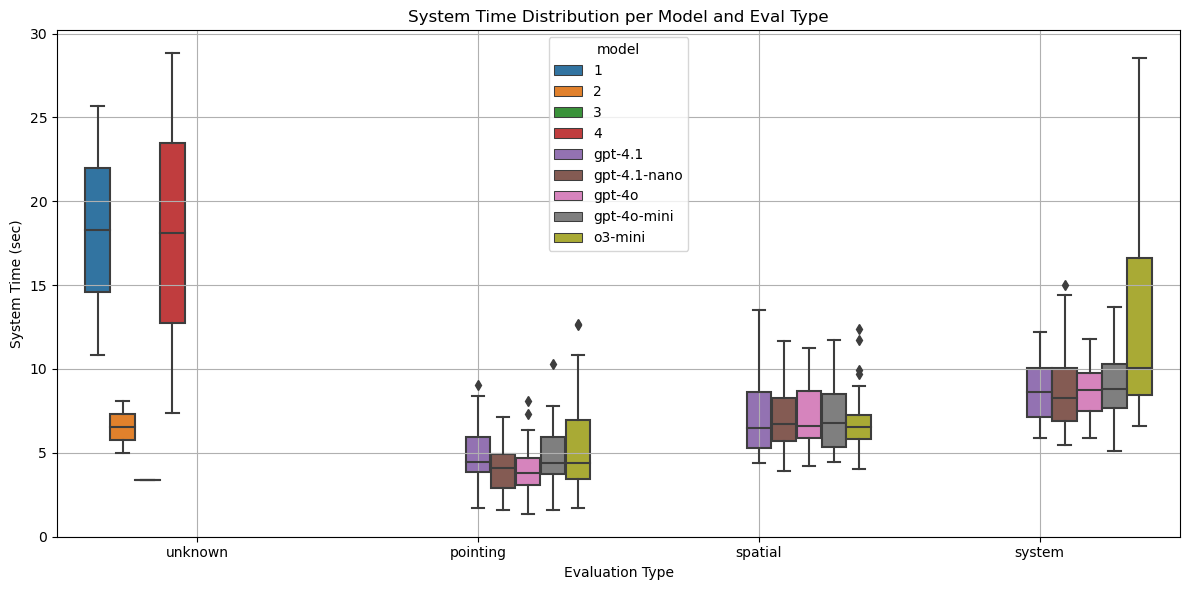

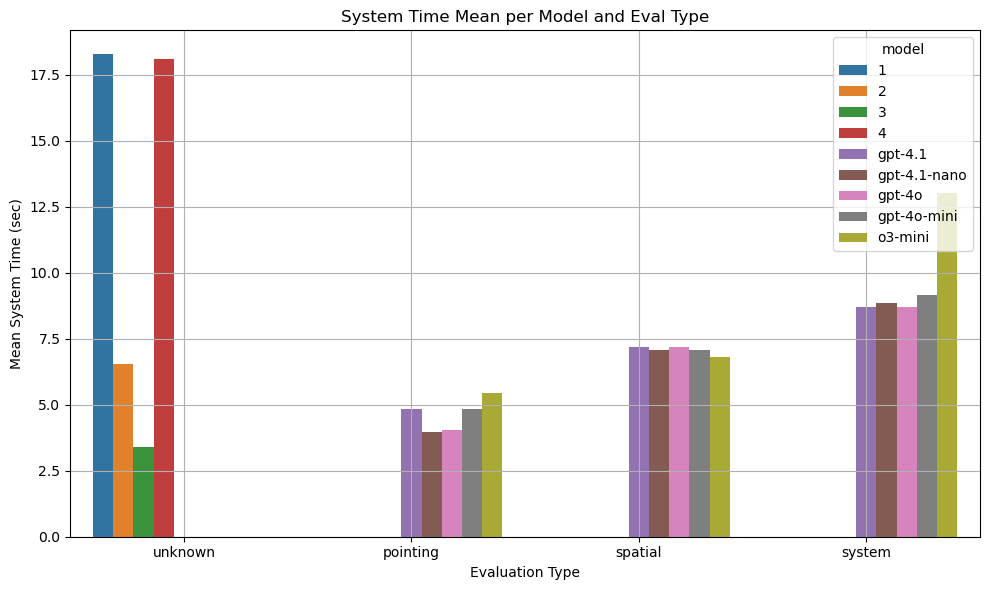

In [8]:
# 生データ取得（箱ひげ図用）
df_raw = collect_raw_system_times(evaluation_results)

# 外れ値除去
df_clean = remove_outliers_iqr_grouped(df_raw, "system_time_sec")

print(df_clean)
# 箱ひげ図！
plot_system_time_boxplot(df_clean)

# 要約統計も取得（平均バー用）
summary = df_clean.groupby(["model", "eval_type"])["system_time_sec"].agg(["min", "max", "mean"]).reset_index()
summary.rename(columns={"mean": "system_time_mean"}, inplace=True)

# バーグラフ！
plot_summary_barplot(summary)


In [11]:
all_device_lists

[{'id': '2125de35-62c2-40db-8bee-f0580a92ee8b', 'name': 'Ceiling Light 1'},
 {'id': '781e6091-cec9-4c26-9f3e-4d48d6d7570a', 'name': 'Ceiling Light 2'},
 {'id': '6f1c35e2-1ca1-4f43-93cf-755d9479025b', 'name': 'Ceiling Light 3'},
 {'id': '6ac4ec9f-0326-4619-b79a-ecbbe5459d23', 'name': 'Ceiling Light 4'},
 {'id': '2dc8ca39-d023-42a5-874d-76fb312b5f00', 'name': 'Ceiling Light 5'},
 {'id': '58126407-cde0-4d62-a13d-1a24bf8ea5f3', 'name': 'Ceiling Light 6'},
 {'id': 'e9a21485-0eb4-40ad-a985-cef8bc98d190', 'name': 'Ceiling Light 7'},
 {'id': '74a6f0f8-be5d-479e-9e08-91d6bd599916', 'name': 'Ceiling Light 8'},
 {'id': 'c689031b-92fe-41bc-a9bc-5f579631c813', 'name': 'Ceiling Light 9'},
 {'id': '541d973c-4101-4118-ae52-f8f192b69655', 'name': 'Ceiling Light 10'},
 {'id': '3da605b5-b12f-4fe8-9108-f4a6648efb3b', 'name': 'Ceiling Light 11'},
 {'id': '10c15b3a-4b64-4eb7-8135-61ea6e1f9182', 'name': 'Ceiling Light 12'},
 {'id': '7b870bf8-74c9-4aac-9e1e-b0e209a6472f', 'name': 'TV Light 1'},
 {'id': '6dc0f

# 性能評価

In [12]:
import pandas as pd

def compute_metrics_per_record(evaluation_results, task_id_to_info, all_device_lists):
    rows = []

    all_device_ids = {d["id"] for d in all_device_lists}

    for model, eval_types in evaluation_results.items():
        for eval_type, records in eval_types.items():
            for record in records:
                task_id = record.get("task_id")
                if task_id not in task_id_to_info:
                    continue

                # Ground truth device IDs
                ground_truth_ids = {d["deviceId"] for d in task_id_to_info[task_id]["devices"]}

                # Predicted device IDs
                if eval_type == "pointing":
                    predicted_ids = {d["id"] for d in record.get("metrics", {}).get("devices", [])}
                elif eval_type == "system":
                    predicted_ids = {d["id"] for d in record.get("filterAgent", {}).get("devices", [])}
                else:
                    predicted_ids = {d["id"] for d in record.get("agent_output", {}).get("devices", [])}

                # Accuracy（完全一致）
                is_exact_match = ground_truth_ids == predicted_ids

                # TP / FP / FN
                tp = len(ground_truth_ids & predicted_ids)
                fp = len(predicted_ids - ground_truth_ids)
                fn = len(ground_truth_ids - predicted_ids)

                # TN
                tn = len(all_device_ids - (ground_truth_ids | predicted_ids))

                # Precision / Recall / F1
                precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
                recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
                f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

                rows.append({
                    "model": model,
                    "eval_type": eval_type,
                    "task_id": task_id,
                    "accuracy": 1.0 if is_exact_match else 0.0,
                    "precision": precision,
                    "recall": recall,
                    "f1_score": f1,
                    "tp": tp,
                    "fp": fp,
                    "fn": fn,
                    "tn": tn,
                    "gt_count": len(ground_truth_ids),
                    "pred_count": len(predicted_ids)
                })

    return pd.DataFrame(rows)


In [13]:
df_melted = pointing_color_summary.melt(
    id_vars='model',
    value_vars=['Accuracy', 'Precision', 'Recall', 'F1'],
    var_name='Metric',
    value_name='Score'
)

# グラフの描画設定
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# グループ化された棒グラフを作成
ax = sns.barplot(data=df_melted, x='model', y='Score', hue='Metric')

# グラフの各種設定
ax.set_title('Model Performance Comparison (Pointing with Color)', fontsize=16)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.1)  # y軸の範囲を0から1.1に設定して見やすくする
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# グラフを表示
plt.show()

NameError: name 'pointing_color_summary' is not defined

In [17]:
df_result = compute_metrics_per_record(evaluation_results, task_id_to_info, all_device_lists)
df_result

,model,eval_type,task_id,accuracy,precision,recall,f1_score,tp,fp,fn,tn,gt_count,pred_count
0,1,unknown,c78550a2-290e-4b94-98db-961c2110c668,1.0,1.000000,1.000000,1.000000,4,0,0,28,4,4
1,1,unknown,c78550a2-290e-4b94-98db-961c2110c668,1.0,1.000000,1.000000,1.000000,4,0,0,28,4,4
2,2,unknown,8aeed698-e7ee-41ef-bfe7-56f37e2232ab,1.0,1.000000,1.000000,1.000000,3,0,0,29,3,3
3,2,unknown,8aeed698-e7ee-41ef-bfe7-56f37e2232ab,1.0,1.000000,1.000000,1.000000,3,0,0,29,3,3
4,3,unknown,2e919b0d-6d84-4641-a535-930a7ca6c8b7,0.0,1.000000,0.333333,0.500000,1,0,2,29,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
682,o3-mini,system,cd873fbb-fcc1-43bd-8f04-bb3b2d716af4,0.0,0.500000,0.833333,0.625000,5,5,1,21,6,10
683,o3-mini,system,ff4748e2-cd97-45bb-bf2c-e5c9c33f78ac,0.0,0.750000,1.000000,0.857143,3,1,0,28,3,4
684,o3-mini,system,4f145d76-f69f-4547-90a7-56281733ca5b,0.0,0.666667,1.000000,0.800000,2,1,0,29,2,3
685,o3-mini,system,137e922c-0877-46af-a797-5a32df2edf5d,0.0,0.333333,1.000000,0.500000,3,6,0,23,3,9


### 平均を見る

In [18]:
print(df_result[["Precision", "Recall", "F1"]].mean())

total_TP = df_result["TP_device"].sum()
total_FP = df_result["FP"].sum()
total_FN = df_result["FN"].sum()

overall_accuracy = total_TP / (total_TP + total_FP + total_FN)

total_tp_color = df_result["TP_device_color"].sum()
total_tp = df_result["TP_device"].sum()
total_fp = df_result["FP"].sum()
total_fn = df_result["FN"].sum()

accuracy_with_color = total_tp_color / (total_tp + total_fp + total_fn)
print(f"Overall Accuracy (without color): {overall_accuracy}　　(with color): {accuracy_with_color:.4f}")


total_color_mismatch = df_result["ColorMismatchCount"].sum()
mean_color_match_rate = df_result["ColorMatchRate"].dropna().mean()


total_color_mismatch, mean_color_match_rate

print(f"Color Math Rate: {mean_color_match_rate}, ColorMismatchCount: {total_color_mismatch}")



KeyError: "None of [Index(['Precision', 'Recall', 'F1'], dtype='object')] are in the [columns]"

In [91]:
# model × eval_type で集計
summary_df = df_result.groupby(["model", "eval_type"]).agg({
    "TP_device": "sum",
    "TP_device_color": "sum",
    "FP": "sum",
    "FN": "sum",
    "Precision": "mean",
    "Recall": "mean",
    "F1": "mean",
    "ColorMatchRate": "mean",
    "system_time_elapsed": ["min", "max", "mean"]
}).reset_index()

# 列名をフラットに整形
summary_df.columns = [
    "Model", "EvalType",
    "TP_device", "TP_device_color", "FP", "FN",
    "Precision", "Recall", "F1", "ColorMatchRate",
    "MinTime", "MaxTime", "AvgTime"
]

# Accuracy（デバイスIDのみ）を計算
summary_df["Accuracy"] = summary_df["TP_device"] / (
    summary_df["TP_device"] + summary_df["FP"] + summary_df["FN"]
)

# Accuracy（デバイスID + 色）を計算
summary_df["Accuracy_Color"] = summary_df["TP_device_color"] / (
    summary_df["TP_device"] + summary_df["FP"] + summary_df["FN"]
)

# 列を整理して最終出力用のDataFrameに整形
summary_df = summary_df[
    ["Model", "EvalType", "Accuracy", "Accuracy_Color", "Precision", "Recall", "F1",
     "ColorMatchRate", "MinTime", "MaxTime", "AvgTime"]
]

summary_df

KeyError: "Column(s) ['F1', 'FN', 'FP', 'Precision', 'Recall', 'TP_device', 'TP_device_color'] do not exist"

In [92]:
total_color_mismatch = summary_df["ColorMismatchCount"].sum()
mean_color_match_rate = summary_df["ColorMatchRate"].dropna().mean()


total_color_mismatch, mean_color_match_rate

NameError: name 'summary_df' is not defined

In [93]:
summary_df = df_result.groupby(["model", "eval_type"])[
    ["Precision", "Recall", "F1", "TP_device", "TP_device_color", "ColorMatchRate", "ColorMismatchCount", "Min]
].mean().reset_index()

summary_df.head()

SyntaxError: unterminated string literal (detected at line 2) (731210055.py, line 2)

In [94]:
def convert_ids_to_names(df, task_id_to_info, all_device_lists):
    # デバイスID → 名前マップ
    device_id_to_name = {d["id"]: d["name"] for d in all_device_lists}

    # task_id → タスク名マップ
    task_id_to_name = {tid: info["name"] for tid, info in task_id_to_info.items()}

    df = df.copy()
    df["task_name"] = df["task_id"].map(task_id_to_name)

    def map_ids_to_names(id_list):
        return [device_id_to_name.get(i, i) for i in id_list]

    df["Correct Devices"] = df["Correct IDs"].apply(map_ids_to_names)
    df["Extra Devices"] = df["Extra IDs"].apply(map_ids_to_names)
    df["Missing Devices"] = df["Missing IDs"].apply(map_ids_to_names)

    # 不要な列を整理
    df = df.drop(columns=["Correct IDs", "Extra IDs", "Missing IDs", "task_id"])
    df = df.rename(columns={"task_name": "Task Name"})

    return df


In [95]:
first_task = evaluation_results["gpt-4o"]["system"][0]
task_id = first_task["task_id"]
agent_devices = first_task["agent_output"]["devices"]
true_devices = task_id_to_info[task_id]["devices"]

print(agent_devices)
print(true_devices)

[{'id': '9cbd6e9a-4f7b-41e8-b1dc-464d631dfd7f', 'state': True, 'intensity': 100, 'color': {'r': 255, 'g': 165, 'b': 0}}, {'id': '6e82a90c-d3bb-4e45-b221-ebe21c524b04', 'state': True, 'intensity': 100, 'color': {'r': 255, 'g': 165, 'b': 0}}]
[{'deviceName': 'Ceiling Light 11', 'colorName': 'Orange', 'deviceId': '3da605b5-b12f-4fe8-9108-f4a6648efb3b'}, {'deviceName': 'Ceiling Light 12', 'colorName': 'Orange', 'deviceId': '10c15b3a-4b64-4eb7-8135-61ea6e1f9182'}]


In [96]:
# RGB→ColorNameマップ（必要に応じて拡張）
RGB_TO_COLOR_NAME = {
    # 基本色
    (255, 0, 0): "Red",
    (0, 128, 0): "Green",
    (0, 0, 255): "Blue",
    
    # 混合色
    (255, 255, 0): "Yellow",
    (0, 255, 255): "Cyan",
    (128, 0, 128): "Purple",
    (255, 165, 0): "Orange",

    # その他
    (255, 255, 255): "White",
    (0, 0, 0): "Black"
}

def rgb_to_name(rgb):
    return RGB_TO_COLOR.get((rgb["r"], rgb["g"], rgb["b"]), "Unknown")

# RGB→ColorNameマップ（必要に応じて拡張可能）
RGB_TO_COLOR = {
    (255, 0, 0): "Red",
    (0, 0, 255): "Blue",
    (0, 255, 0): "Green",
    (255, 255, 0): "Yellow",
    (255, 255, 255): "White",
    (255, 165, 0): "Orange",
    (128, 0, 128): "Purple",
    (0, 255, 255): "Cyan"
}

def rgb_to_name(rgb):
    return RGB_TO_COLOR.get((rgb["r"], rgb["g"], rgb["b"]), "Unknown")

def evaluate_device_and_color(agent_devices, true_devices, all_device_ids):
    # ---------- ground-truth 辞書 ----------
    true_id_to_color = {d["deviceId"]: d["colorName"] for d in true_devices}

    # ---------- ID レベル ----------
    predicted_ids = {d["id"] for d in agent_devices}
    true_ids      = set(true_id_to_color.keys())

    id_TP = predicted_ids & true_ids
    id_FP = predicted_ids - true_ids
    id_FN = true_ids     - predicted_ids
    id_TN = all_device_ids - (predicted_ids | true_ids)

    # ---------- 色レベル ----------
    color_TP = set()
    color_FP = set()

    for d in agent_devices:
        did = d["id"]
        if did in id_TP:
            pred_color  = rgb_to_name(d["color"])
            true_color  = true_id_to_color[did]
            if pred_color == true_color:
                color_TP.add(did)
            else:
                color_FP.add(did)

    color_FN = {did for did in true_ids if did not in color_TP}

    # ---------- 指標計算 ----------
    def _prf(tp, fp, fn):
        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall    = tp / (tp + fn) if (tp + fn) else 0.0
        f1        = 2*precision*recall/(precision+recall) if (precision+recall) else 0.0
        return precision, recall, f1

    prec_id, rec_id, f1_id = _prf(len(id_TP), len(id_FP), len(id_FN))
    prec_col, rec_col, f1_col = _prf(len(color_TP), len(color_FP) + len(id_FP), len(color_FN))

    accuracy_id = (len(id_TP) + len(id_TN)) / (len(all_device_ids)) if all_device_ids else 0.0

    return {
        "no_color_metric": {
            "TP": len(id_TP),
            "FP": len(id_FP),
            "FN": len(id_FN),
            "TN": len(id_TN),
            "Precision": prec_id,
            "Recall":    rec_id,
            "F1":        f1_id,
            "Accuracy":  accuracy_id
        },
        "color_metric": {
            "TP": len(color_TP),
            "FP": len(color_FP) + len(id_FP),
            "FN": len(color_FN),
            "Precision": prec_col,
            "Recall":    rec_col,
            "F1":        f1_col
        },
        "ColorMatchRate": len(color_TP) / len(id_TP) if id_TP else None,
        "CorrectIDs":  list(id_TP),
        "ExtraIDs":    list(id_FP),
        "MissingIDs":  list(id_FN),
        "ColorMismatchIDs": list(color_FP),
    }


import pandas as pd

def remove_outliers_and_aggregate_by_model(df_result):
    grouped_results = []

    for model, group in df_result.groupby("model"):
        times = group["system_time_elapsed"]

        # 四分位数とIQRを計算
        Q1 = times.quantile(0.25)
        Q3 = times.quantile(0.75)
        IQR = Q3 - Q1

        # 外れ値のしきい値
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # 外れ値除去
        filtered = group[(times >= lower_bound) & (times <= upper_bound)]

        # 指標を集計
        result = {
            "model": model,
            "system_time_min": filtered["system_time_elapsed"].min(),
            "system_time_max": filtered["system_time_elapsed"].max(),
            "system_time_mean": filtered["system_time_elapsed"].mean(),
            "system_time_std": filtered["system_time_elapsed"].std(),
            "removed_outliers": len(group) - len(filtered),
            "retained_count": len(filtered)
        }
        grouped_results.append(result)

    return pd.DataFrame(grouped_results)



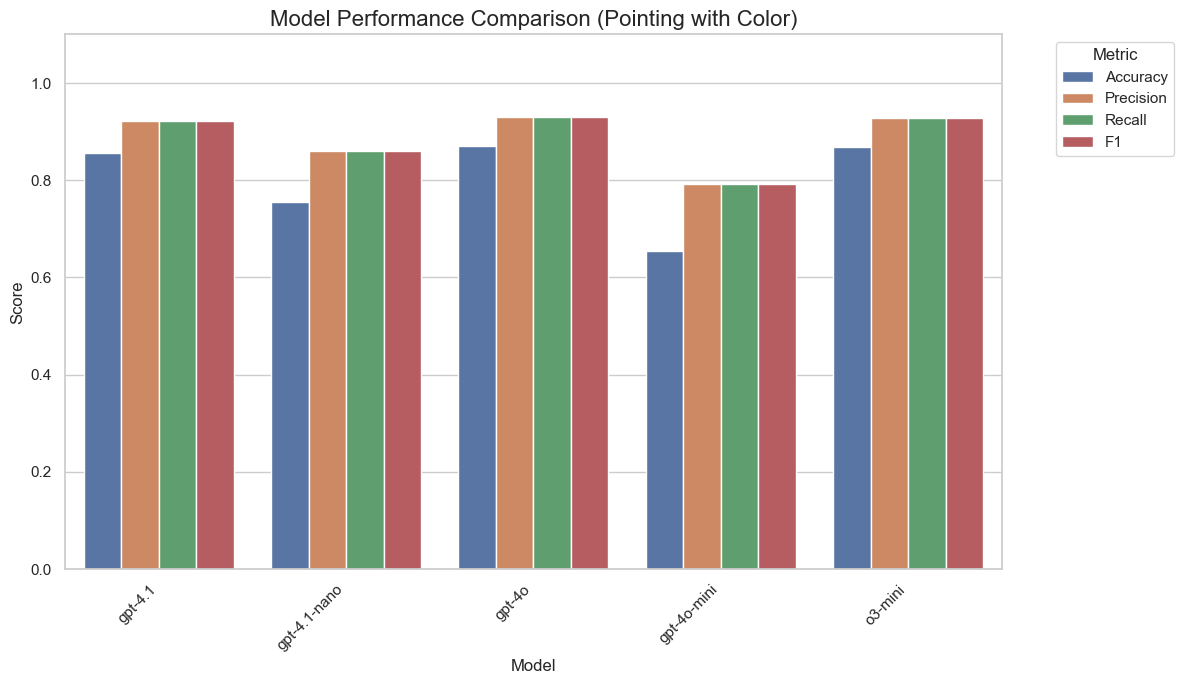

In [97]:
df_melted = pointing_color_summary.melt(
    id_vars='model',
    value_vars=['Accuracy', 'Precision', 'Recall', 'F1'],
    var_name='Metric',
    value_name='Score'
)

# グラフの描画設定
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# グループ化された棒グラフを作成
ax = sns.barplot(data=df_melted, x='model', y='Score', hue='Metric')

# グラフの各種設定
ax.set_title('Model Performance Comparison (Pointing with Color)', fontsize=16)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.1)  # y軸の範囲を0から1.1に設定して見やすくする
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# グラフを表示
plt.show()

# 結果を計算する　（これが今メインコード）

In [98]:
import pandas as pd
results_summary = []

all_device_ids = {d["id"] for d in all_device_lists}

        
for model, model_result in evaluation_results.items():
    for eval_type, records in model_result.items():
        for record in records:
            task_id = record["task_id"]
            agent_devices = record["agent_output"]["devices"]
            true_devices = task_id_to_info[task_id]["devices"]
            result["system_time_elapsed"] = record["system_total_time_sec"]
            result = evaluate_device_and_color(agent_devices, true_devices, all_device_ids)
            result["task_id"] = task_id
            result["model"] = model
            result["eval_type"] = eval_type
            results_summary.append(result)

df_result = pd.DataFrame(results_summary)
df_result.head()

,no_color_metric,color_metric,ColorMatchRate,CorrectIDs,ExtraIDs,MissingIDs,ColorMismatchIDs,task_id,model,eval_type,system_time_elapsed
0,"{'TP': 4, 'FP': 0, 'FN': 0, 'TN': 28, 'Precisi...","{'TP': 4, 'FP': 0, 'FN': 0, 'Precision': 1.0, ...",1.000000,"[58126407-cde0-4d62-a13d-1a24bf8ea5f3, 2125de3...",[],[],[],c78550a2-290e-4b94-98db-961c2110c668,1,unknown,10.851065
1,"{'TP': 4, 'FP': 0, 'FN': 0, 'TN': 28, 'Precisi...","{'TP': 4, 'FP': 0, 'FN': 0, 'Precision': 1.0, ...",1.000000,"[58126407-cde0-4d62-a13d-1a24bf8ea5f3, 2125de3...",[],[],[],c78550a2-290e-4b94-98db-961c2110c668,1,unknown,4.990211
2,"{'TP': 3, 'FP': 0, 'FN': 0, 'TN': 29, 'Precisi...","{'TP': 3, 'FP': 0, 'FN': 0, 'Precision': 1.0, ...",1.000000,"[7ad8857c-4547-4f42-bcc0-dc17bd8e6fee, 80e64f7...",[],[],[],8aeed698-e7ee-41ef-bfe7-56f37e2232ab,2,unknown,8.067839
3,"{'TP': 3, 'FP': 0, 'FN': 0, 'TN': 29, 'Precisi...","{'TP': 2, 'FP': 1, 'FN': 1, 'Precision': 0.666...",0.666667,"[7ad8857c-4547-4f42-bcc0-dc17bd8e6fee, 80e64f7...",[],[],[80e64f7b-0589-4de7-977a-9d189a66fd1d],8aeed698-e7ee-41ef-bfe7-56f37e2232ab,2,unknown,3.393032
4,"{'TP': 1, 'FP': 0, 'FN': 2, 'TN': 29, 'Precisi...","{'TP': 1, 'FP': 0, 'FN': 2, 'Precision': 1.0, ...",1.000000,[badaeb49-9e87-4d7b-882e-be2e80f85c84],[],"[6e82a90c-d3bb-4e45-b221-ebe21c524b04, 9cbd6e9...",[],2e919b0d-6d84-4641-a535-930a7ca6c8b7,3,unknown,7.350140


In [99]:
import pandas as pd

# ───────────────────────────────────────────────
#  Series(dict) → TP/FP/FN Precision / Recall / F1 / Accuracy
# ───────────────────────────────────────────────
def _aggregate_metric_column(series_of_dicts: pd.Series) -> dict:
    df = series_of_dicts.apply(pd.Series)

    tp = df["TP"].sum()
    fp = df["FP"].sum()
    fn = df["FN"].sum()
    tn = df["TN"].sum() if "TN" in df.columns else 0  # ← 追加！

    precision = tp / (tp + fp) if tp + fp else 0.0
    recall    = tp / (tp + fn) if tp + fn else 0.0
    f1        = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    accuracy  = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) else 0.0  # ← Accuracy 修正

    return {
        "TP"       : int(tp),
        "FP"       : int(fp),
        "FN"       : int(fn),
        "TN"       : int(tn),
        "Precision": precision,
        "Recall"   : recall,
        "F1"       : f1,
        "Accuracy" : accuracy
    }

# ───────────────────────────────────────────────
#  モデル×評価タイプでまとめる  (ネスト辞書を持つ行を生成)
# ───────────────────────────────────────────────
def summarize_by_model_and_evaltype(df_result: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for (model, etype), grp in df_result.groupby(["model", "eval_type"]):
        # ---- 色なし / 色あり ----
        nc = _aggregate_metric_column(grp["no_color_metric"])
        wc = _aggregate_metric_column(grp["color_metric"])

        # ---- 時間統計 ----
        min_t = grp["system_time_elapsed"].min()
        max_t = grp["system_time_elapsed"].max()
        avg_t = grp["system_time_elapsed"].mean()
        cmr = grp["ColorMatchRate"].mean()

        rows.append({
            "model"         : model,
            "eval_type"     : etype,
            "no_color_metric": nc,
            "color_metric"   : wc,
            "color_match_rate": cmr,
            "min_time"       : float(min_t),
            "max_time"       : float(max_t),
            "avg_time"       : float(avg_t)
        })

    # 列順は必要に応じて調整
    return pd.DataFrame(rows, columns=[
        "model", "eval_type",
        "no_color_metric", "color_metric","color_match_rate",
        "min_time", "max_time", "avg_time"
    ])

# ----------------------------- 使い方 -----------------------------
summary_all  = pd.DataFrame(summarize_by_model_and_evaltype(df_result))
summary_all.iloc[0]["color_metric"]

{'TP': 8,
 'FP': 0,
 'FN': 0,
 'TN': 0,
 'Precision': 1.0,
 'Recall': 1.0,
 'F1': 1.0,
 'Accuracy': 1.0}

In [120]:
import pandas as pd



def extract_color_mode_from_summary_all(summary_all, eval_type, with_color):
    df_point = summary_all[summary_all["eval_type"] == eval_type].copy()
    
    # color_metric or no_color_metric を展開
    metric_key = "color_metric" if with_color else "no_color_metric"
    metric_df = df_point[metric_key].apply(pd.Series)

    # base列（color_match_rate や時間）
    base_cols = ["model", "eval_type"]
    if "color_match_rate" in df_point.columns:
        base_cols.append("color_match_rate")
    if "min_time" in df_point.columns:
        base_cols.extend(["min_time", "max_time", "avg_time"])

    # 並べる順番（TN を追加！）
    metric_cols = ["Accuracy", "Precision", "Recall", "F1", "TP", "FP", "FN"]
    if "TN" in metric_df.columns:
        metric_cols.append("TN")

    table = (
        pd.concat([df_point[base_cols], metric_df], axis=1)
          .loc[:, ["model"] + metric_cols + [col for col in ["color_match_rate", "min_time", "max_time", "avg_time"] if col in df_point.columns]]
          .reset_index(drop=True)
    )
    return table


spatial_color_summary = extract_color_mode_from_summary_all(summary_all,"spatial", True)
system_color_summary = extract_color_mode_from_summary_all(summary_all,"system", True)
pointing_color_summary  = extract_color_mode_from_summary_all(summary_all,"pointing", True)


spatial_no_summary = extract_color_mode_from_summary_all(summary_all,"spatial", False)
system_no_summary = extract_color_mode_from_summary_all(summary_all,"system", False)
pointing_no_summary  = extract_color_mode_from_summary_all(summary_all,"pointing", False)


print("")
pointing_no_summary



,model,Accuracy,Precision,Recall,F1,TP,FP,FN,TN,color_match_rate,min_time,max_time,avg_time
0,gpt-4.1,1.000000,1.000000,1.000000,1.000000,141.0,0.0,0.0,1331.0,0.931159,1.694347,14.631763,5.514875
1,gpt-4.1-nano,1.000000,1.000000,1.000000,1.000000,144.0,0.0,0.0,1360.0,0.882979,1.588022,13.121582,4.729586
2,gpt-4o,1.000000,1.000000,1.000000,1.000000,144.0,0.0,0.0,1360.0,0.932624,1.366126,13.251957,4.744034
3,gpt-4o-mini,0.996019,0.979167,0.979167,0.979167,141.0,3.0,3.0,1360.0,0.842790,1.577704,14.860325,5.791248
4,o3-mini,1.000000,1.000000,1.000000,1.000000,141.0,0.0,0.0,1331.0,0.942029,1.698868,14.266431,5.901033


In [121]:
import pandas as pd

import pandas as pd

def dataframe_to_latex(
    df_color: pd.DataFrame,
    df_no_color: pd.DataFrame,
    caption_main: str,
    caption_metrics: str,
    caption_time: str,
    caption_nocolor: str,
    label_main: str,
    label_metrics: str,
    label_time: str,
    label_nocolor: str,
    use_small_font: bool = False,
) -> str:
    def make_styler(df: pd.DataFrame) -> pd.DataFrame:
        sty = pd.DataFrame("", index=df.index, columns=df.columns)
        low_is_good = ["FP", "FN", "min_time", "max_time", "avg_time"]
        for col in df.select_dtypes(include="number").columns:
            if df[col].nunique() < 2:
                continue
            best, worst = (
                (df[col].idxmin(), df[col].idxmax())
                if col in low_is_good
                else (df[col].idxmax(), df[col].idxmin())
            )
            if best != worst:
                sty.at[best, col] = r"\cellcolor{green!25}"
                sty.at[worst, col] = r"\cellcolor{red!25}"
        return sty

    df_c = df_color.set_index("model")
    df_nc = df_no_color.set_index("model")
    sty_c, sty_nc = make_styler(df_c), make_styler(df_nc)

    metric_cols = ["Accuracy", "color_match_rate", "Precision", "Recall", "F1", "TP",  "TN", "FP", "FN"]
    time_cols = ["min_time", "max_time", "avg_time"]
    nocolor_cols = ["Accuracy", "Precision", "Recall", "F1", "TP", "TN", "FP", "FN"]

    fmt = {c: ".3f" for c in ["Accuracy", "color_match_rate", "Precision", "Recall", "F1"]}
    fmt.update({"TP": "d", "FP": "d", "FN": "d", "TN": "d", "min_time": ".2f", "max_time": ".2f", "avg_time": ".2f"})

    def subtable(df, styler, cols, subcap, sublabel):
        col_fmt = "l|" + "c" * len(cols)
        lines = [
            r"\begin{subtable}[t]{\linewidth}",
            r"\centering",
            rf"\caption{{{subcap}}}",
            rf"\label{{tab:{sublabel}}}",
        ]
        if use_small_font:
            lines.append(r"\small")

        header = " & ".join([rf"\textbf{{{c.replace('_', ' ').title()[:5]}}}" for c in cols])
        lines += [
            rf"\begin{{tabular}}{{{col_fmt}}}",
            r"\toprule",
            rf"\textbf{{Model}} & {header} \\",
            r"\midrule",
        ]

        for mdl in df.index:
            row = [mdl]
            for c in cols:
                v = df.loc[mdl, c]
                sty = styler.loc[mdl, c] if c in styler.columns else ""
                f = fmt.get(c, ".3f")
                txt = f"{int(v):d}" if f == "d" else f"{v:{f}}" if pd.notna(v) else ""
                row.append(f"{sty}{txt}")
            lines.append(" & ".join(row) + r" \\")

        lines += [r"\bottomrule", r"\end{tabular}", r"\end{subtable}", ""]
        return lines

    out = [
        r"\begin{table*}[htbp]",
        r"\centering",
        rf"\caption{{{caption_main}}}",
        rf"\label{{tab:{label_main}}}",
    ]
    out += subtable(df_c, sty_c, metric_cols, caption_metrics, label_metrics)
    out += [r"\par\medskip"]
    out += subtable(df_c, sty_c, time_cols, caption_time, label_time)
    out += [r"\par\bigskip"]
    out += subtable(df_nc, sty_nc, nocolor_cols, caption_nocolor, label_nocolor)
    out += [r"\end{table*}"]

    return "\n".join(out)



# 例：モデル別に平均値を集計（Colorあり評価用）
system_color_summary = (
    df_result[df_result["eval_type"] == "system"]
    .assign(model=lambda x: x["model"])
    .groupby("model")
    .apply(lambda g: pd.Series({
        "Accuracy": g["no_color_metric"].apply(lambda x: x["Accuracy"]).mean(),
        "color_match_rate": g["ColorMatchRate"].mean(),
        "Precision": g["color_metric"].apply(lambda x: x["Precision"]).mean(),
        "Recall": g["color_metric"].apply(lambda x: x["Recall"]).mean(),
        "F1": g["color_metric"].apply(lambda x: x["F1"]).mean(),
        "TP": g["color_metric"].apply(lambda x: x["TP"]).sum(),
        "FP": g["color_metric"].apply(lambda x: x["FP"]).sum(),
        "FN": g["color_metric"].apply(lambda x: x["FN"]).sum(),
        "TN": g["no_color_metric"].apply(lambda x: x["TN"]).sum(),
        "min_time": g["system_time_elapsed"].min(),
        "max_time": g["system_time_elapsed"].max(),
        "avg_time": g["system_time_elapsed"].mean()
    }))
).reset_index()

latex_code = dataframe_to_latex(
    df_color=pointing_color_summary,
    df_no_color=pointing_no_summary,
    caption_main="Performance Comparison: Pointing + Spatial Reasoning Agent",
    caption_metrics="Device Selection and Color",
    caption_time="Device Selection and Color (s)",
    caption_nocolor="Device Selection Only",
    label_main="pointing_performance_table",
    label_metrics="pointing_color_metrics",
    label_time="pointing_color_time",
    label_nocolor="system_nocolor",
    use_small_font=False,
)



print(latex_code)

\begin{table*}[htbp]
\centering
\caption{Performance Comparison: Pointing + Spatial Reasoning Agent}
\label{tab:pointing_performance_table}
\begin{subtable}[t]{\linewidth}
\centering
\caption{Device Selection and Color}
\label{tab:pointing_color_metrics}
\begin{tabular}{l|ccccccccc}
\toprule
\textbf{Model} & \textbf{Accur} & \textbf{Color} & \textbf{Preci} & \textbf{Recal} & \textbf{F1} & \textbf{Tp} & \textbf{Tn} & \textbf{Fp} & \textbf{Fn} \\
\midrule
gpt-4.1 & 0.855 & 0.931 & 0.922 & 0.922 & 0.922 & 130 & 0 & 11 & 11 \\
gpt-4.1-nano & 0.756 & 0.883 & 0.861 & 0.861 & 0.861 & 124 & 0 & 20 & 20 \\
gpt-4o & \cellcolor{green!25}0.870 & 0.933 & \cellcolor{green!25}0.931 & \cellcolor{green!25}0.931 & \cellcolor{green!25}0.931 & \cellcolor{green!25}134 & 0 & \cellcolor{green!25}10 & \cellcolor{green!25}10 \\
gpt-4o-mini & \cellcolor{red!25}0.655 & \cellcolor{red!25}0.843 & \cellcolor{red!25}0.792 & \cellcolor{red!25}0.792 & \cellcolor{red!25}0.792 & \cellcolor{red!25}114 & 0 & \cellcolor{re

In [113]:
print(system_no_summary.columns)

Index(['model', 'Accuracy', 'Precision', 'Recall', 'F1', 'TP', 'FP', 'FN',
       'TN', 'color_match_rate', 'min_time', 'max_time', 'avg_time'],
      dtype='object')


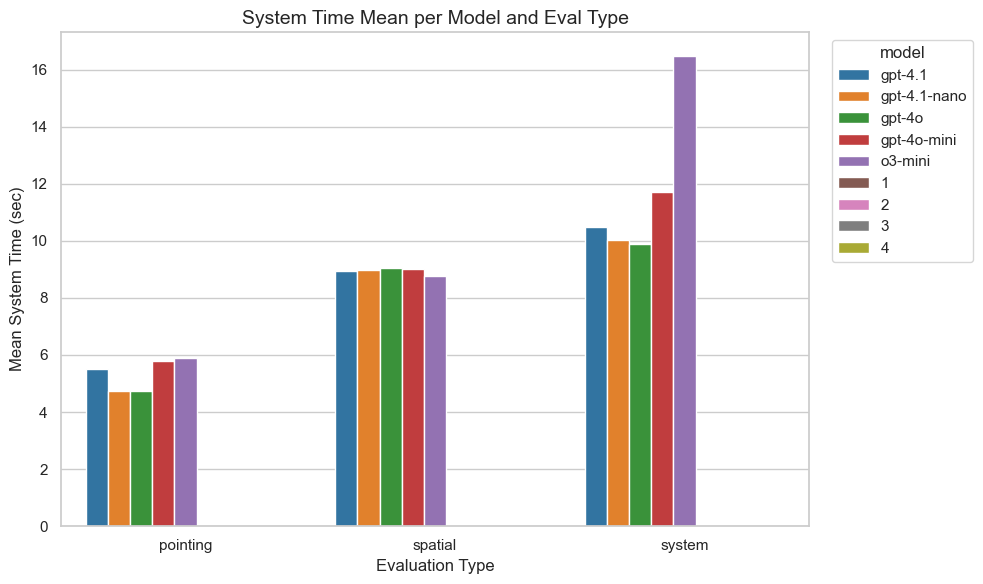

In [114]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------
# ① summary_all から時間データだけ抽出
#    必要な列: model, eval_type, avg_time
# -------------------------------------------------
time_df = summary_all[["model", "eval_type", "avg_time"]].copy()

# eval_type の並び順を明示的に決めたい場合
eval_order = ["pointing", "spatial", "system"]
time_df["eval_type"] = pd.Categorical(time_df["eval_type"], categories=eval_order, ordered=True)
time_df = time_df.sort_values(["eval_type", "model"])

# -------------------------------------------------
# ② 描画 (seaborn の barplot で “グループ化棒グラフ”)
# -------------------------------------------------
plt.figure(figsize=(10, 6))

sns.barplot(
    data   = time_df,
    x      = "eval_type",
    y      = "avg_time",
    hue    = "model",
    palette = "tab10"
)

plt.title("System Time Mean per Model and Eval Type", fontsize=14)
plt.xlabel("Evaluation Type")
plt.ylabel("Mean System Time (sec)")
plt.legend(title="model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()



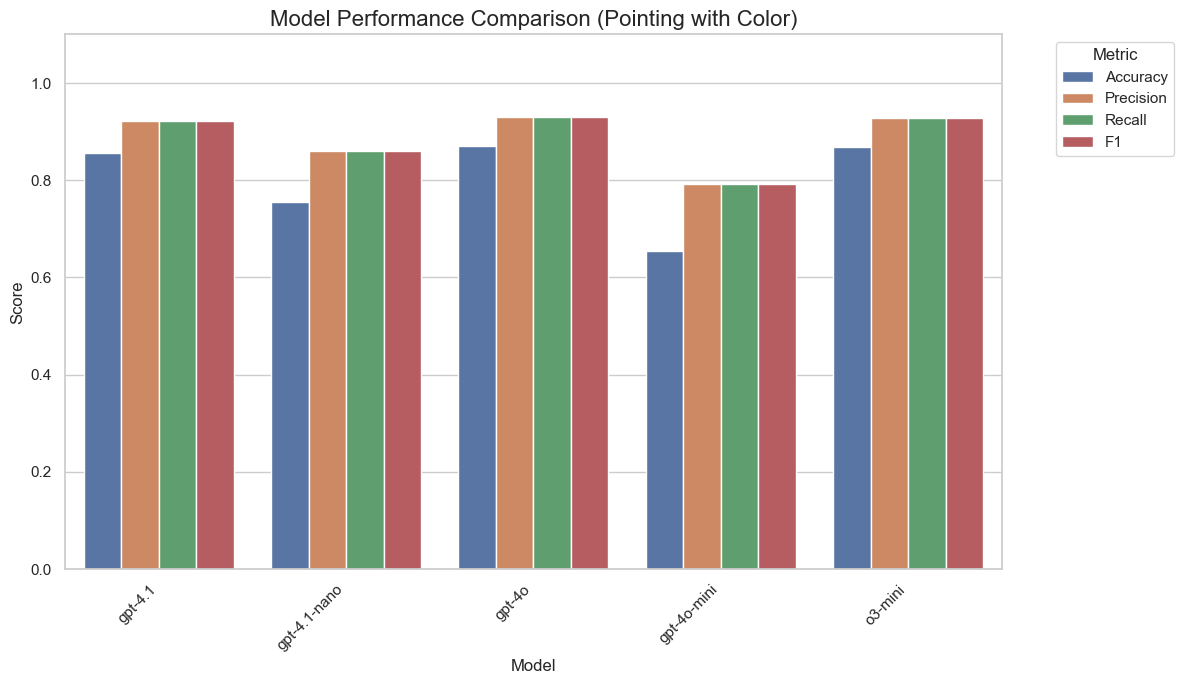

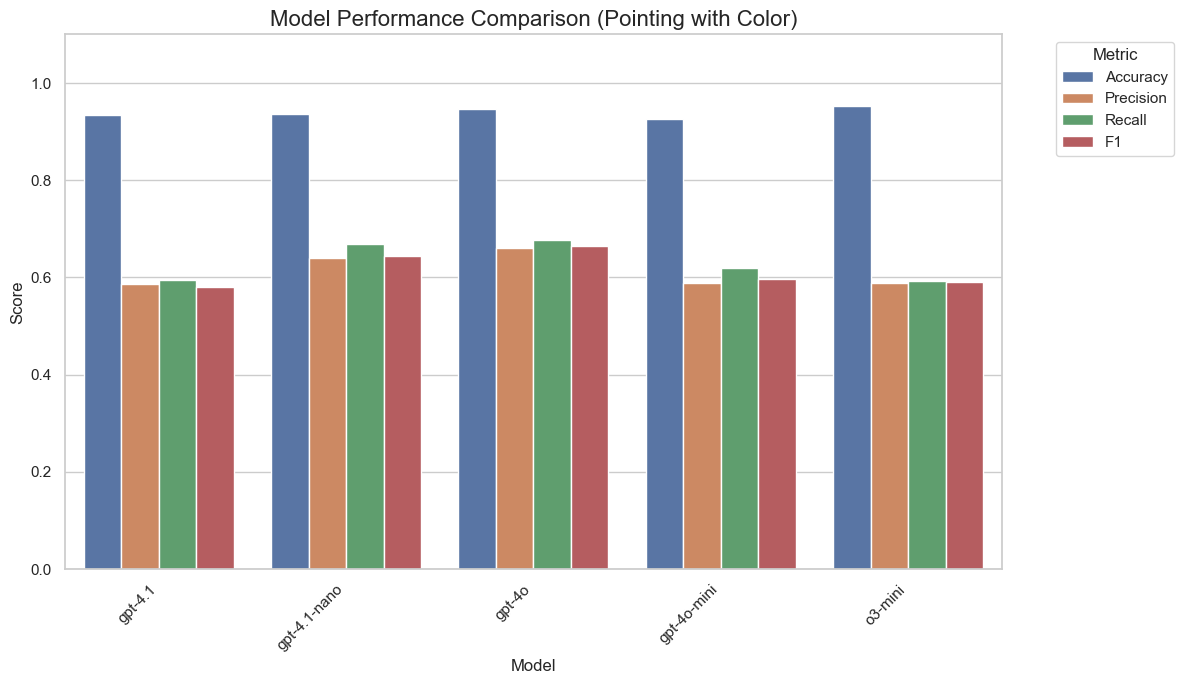

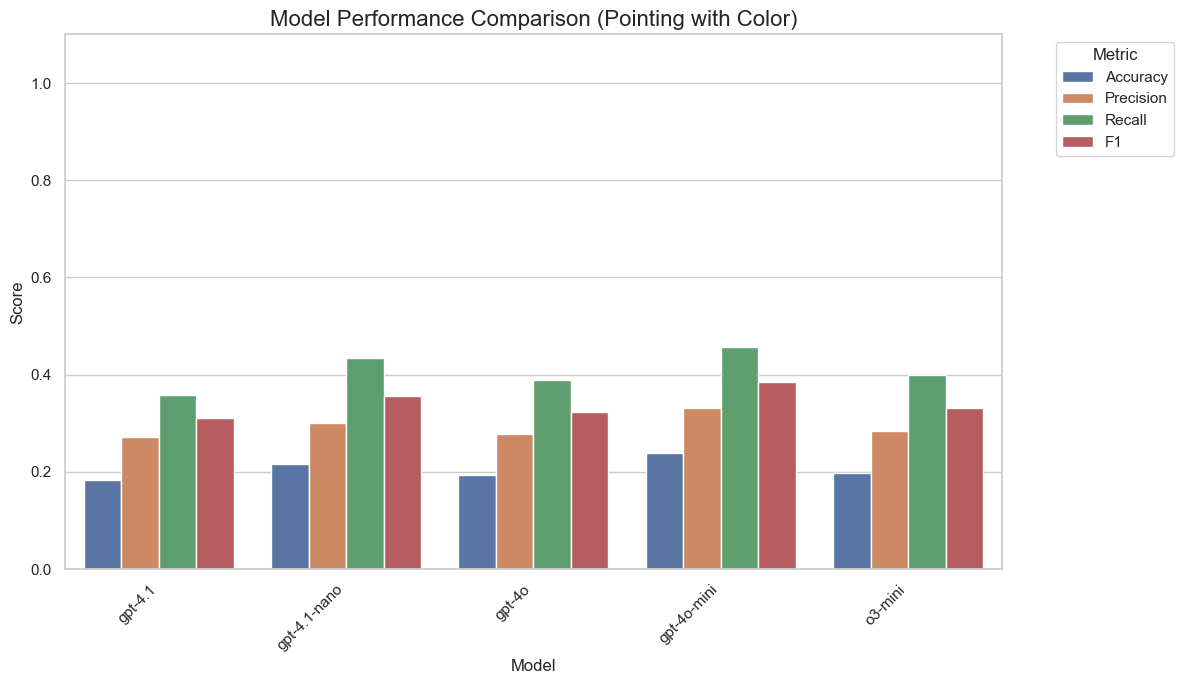

In [115]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



#================== Pointing =============================
# データを可視化に適した形式（ロングフォーマット）に変換
df_melted = pointing_color_summary.melt(
    id_vars='model',
    value_vars=['Accuracy', 'Precision', 'Recall', 'F1'],
    var_name='Metric',
    value_name='Score'
)

# グラフの描画設定
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# グループ化された棒グラフを作成
ax = sns.barplot(data=df_melted, x='model', y='Score', hue='Metric')

# グラフの各種設定
ax.set_title('Model Performance Comparison (Pointing with Color)', fontsize=16)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.1)  # y軸の範囲を0から1.1に設定して見やすくする
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# グラフを表示
plt.show()





#======================= System ========================================

# データを可視化に適した形式（ロングフォーマット）に変換
df_melted = system_color_summary.melt(
    id_vars='model',
    value_vars=['Accuracy', 'Precision', 'Recall', 'F1'],
    var_name='Metric',
    value_name='Score'
)

# グラフの描画設定
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# グループ化された棒グラフを作成
ax = sns.barplot(data=df_melted, x='model', y='Score', hue='Metric')

# グラフの各種設定
ax.set_title('Model Performance Comparison (Pointing with Color)', fontsize=16)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.1)  # y軸の範囲を0から1.1に設定して見やすくする
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# グラフを表示
plt.show()

# ====================================Spatial============================================

# データを可視化に適した形式（ロングフォーマット）に変換
df_melted = spatial_color_summary.melt(
    id_vars='model',
    value_vars=['Accuracy', 'Precision', 'Recall', 'F1'],
    var_name='Metric',
    value_name='Score'
)

# グラフの描画設定
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# グループ化された棒グラフを作成
ax = sns.barplot(data=df_melted, x='model', y='Score', hue='Metric')

# グラフの各種設定
ax.set_title('Model Performance Comparison (Pointing with Color)', fontsize=16)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.1)  # y軸の範囲を0から1.1に設定して見やすくする
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# グラフを表示
plt.show()

#　ここから古いの

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = df_result.copy()
df_plot["Accuracy"] = df_plot["TP_device"] / (df_plot["TP_device"] + df_plot["FP"] + df_plot["FN"])
df_plot["Accuracy_with_color"] = df_plot["TP_device_color"] / (df_plot["TP_device"] + df_plot["FP"] + df_plot["FN"])

# モデル×評価タイプごとの平均
agg = df_plot.groupby(["model", "eval_type"])[["Accuracy", "Accuracy_with_color"]].mean().reset_index()

# 棒グラフ化
plt.figure(figsize=(12, 6))
sns.barplot(data=agg, x="eval_type", y="Accuracy", hue="model")
plt.title("Accuracy (without color) per model/eval_type")
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=agg, x="eval_type", y="Accuracy_with_color", hue="model")
plt.title("Accuracy (with color) per model/eval_type")
plt.ylim(0, 1)
plt.show()


KeyError: 'TP_device'

In [56]:
pointing_data = evaluation_results["gpt-4o"]["pointing"]

# 各pointed_devicesの長さを集めて平均を取る
candidate_counts = [len(entry["pointed_devices"]) for entry in pointing_data]
average_candidates = sum(candidate_counts) / len(candidate_counts)

print(f"Average number of pointed candidate devices: {average_candidates:.2f}")

Average number of pointed candidate devices: 3.06


In [57]:
# 各タスクセットのデバイス数をリスト化
device_counts = [len(task_set["devices"]) for task_set in all_task_sets]

# 平均を計算
average_devices_per_task = sum(device_counts) / len(device_counts)

print(f"平均デバイス数: {average_devices_per_task:.2f}")


平均デバイス数: 3.02


In [58]:
system_data = evaluation_results["gpt-4o"]["system"]

# 各試行における FilterAgent のデバイス数を抽出
filter_candidate_counts = [
    len(entry["filterAgent"]["devices"])
    for entry in system_data
    if "filterAgent" in entry and "devices" in entry["filterAgent"]
]

# 平均を計算
average_filter_candidates = sum(filter_candidate_counts) / len(filter_candidate_counts)

print(f"平均FilterAgent候補デバイス数 (system): {average_filter_candidates:.2f}")


平均FilterAgent候補デバイス数 (system): 7.18


In [59]:
system_data = evaluation_results["gpt-4o"]["system"]

# 各試行で選ばれたデバイスの数
selected_counts = [len(entry["selected_devices"]) for entry in system_data]

# 平均を計算
average_selected = sum(selected_counts) / len(selected_counts)

print(f"平均選択デバイス数 (system): {average_selected:.2f}")


平均選択デバイス数 (system): 3.62


In [60]:
system_data = evaluation_results["gpt-4o"]["spatial"]

# 各試行で選ばれたデバイスの数
selected_counts = [len(entry["selected_devices"]) for entry in system_data]

# 平均を計算
average_selected = sum(selected_counts) / len(selected_counts)

print(f"平均選択デバイス数 (system): {average_selected:.2f}")

平均選択デバイス数 (system): 4.30


# Add TN

In [144]:
# RGB→ColorNameマップ（必要に応じて拡張）
RGB_TO_COLOR_NAME = {
    # 基本色
    (255, 0, 0): "Red",
    (0, 128, 0): "Green",
    (0, 0, 255): "Blue",
    
    # 混合色
    (255, 255, 0): "Yellow",
    (0, 255, 255): "Cyan",
    (128, 0, 128): "Purple",
    (255, 165, 0): "Orange",

    # その他
    (255, 255, 255): "White",
    (0, 0, 0): "Black"
}

def rgb_to_name(rgb):
    return RGB_TO_COLOR.get((rgb["r"], rgb["g"], rgb["b"]), "Unknown")

# RGB→ColorNameマップ（必要に応じて拡張可能）
RGB_TO_COLOR = {
    (255, 0, 0): "Red",
    (0, 0, 255): "Blue",
    (0, 255, 0): "Green",
    (255, 255, 0): "Yellow",
    (255, 255, 255): "White",
    (255, 165, 0): "Orange",
    (128, 0, 128): "Purple",
    (0, 255, 255): "Cyan"
}

def rgb_to_name(rgb):
    return RGB_TO_COLOR.get((rgb["r"], rgb["g"], rgb["b"]), "Unknown")

def evaluate_device_and_color(agent_devices, true_devices, all_device_ids):
    # ---------- ground-truth 辞書 ----------
    true_id_to_color = {d["deviceId"]: d["colorName"] for d in true_devices}

    # ---------- ID レベル ----------
    predicted_ids = {d["id"] for d in agent_devices}
    true_ids      = set(true_id_to_color.keys())

    id_TP = predicted_ids & true_ids
    id_FP = predicted_ids - true_ids
    id_FN = true_ids     - predicted_ids
    id_TN = all_device_ids - (predicted_ids | true_ids)

    # ---------- 色レベル ----------
    color_TP = set()
    color_FP = set()

    for d in agent_devices:
        did = d["id"]
        if did in id_TP:
            pred_color  = rgb_to_name(d["color"])
            true_color  = true_id_to_color[did]
            if pred_color == true_color:
                color_TP.add(did)
            else:
                color_FP.add(did)

    color_FN = {did for did in true_ids if did not in color_TP}

    # ---------- 指標計算 ----------
    def _prf(tp, fp, fn):
        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall    = tp / (tp + fn) if (tp + fn) else 0.0
        f1        = 2*precision*recall/(precision+recall) if (precision+recall) else 0.0
        return precision, recall, f1

    prec_id, rec_id, f1_id = _prf(len(id_TP), len(id_FP), len(id_FN))
    prec_col, rec_col, f1_col = _prf(len(color_TP), len(color_FP) + len(id_FP), len(color_FN))

    accuracy_id = (len(id_TP) + len(id_TN)) / (len(all_device_ids)) if all_device_ids else 0.0

    return {
        "no_color_metric": {
            "TP": len(id_TP),
            "FP": len(id_FP),
            "FN": len(id_FN),
            "TN": len(id_TN),
            "Precision": prec_id,
            "Recall":    rec_id,
            "F1":        f1_id,
            "Accuracy":  accuracy_id
        },
        "color_metric": {
            "TP": len(color_TP),
            "FP": len(color_FP) + len(id_FP),
            "FN": len(color_FN),
            "Precision": prec_col,
            "Recall":    rec_col,
            "F1":        f1_col
        },
        "ColorMatchRate": len(color_TP) / len(id_TP) if id_TP else None,
        "CorrectIDs":  list(id_TP),
        "ExtraIDs":    list(id_FP),
        "MissingIDs":  list(id_FN),
        "ColorMismatchIDs": list(color_FP),
    }


import pandas as pd

def remove_outliers_and_aggregate_by_model(df_result):
    grouped_results = []

    for model, group in df_result.groupby("model"):
        times = group["system_time_elapsed"]

        # 四分位数とIQRを計算
        Q1 = times.quantile(0.25)
        Q3 = times.quantile(0.75)
        IQR = Q3 - Q1

        # 外れ値のしきい値
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # 外れ値除去
        filtered = group[(times >= lower_bound) & (times <= upper_bound)]

        # 指標を集計
        result = {
            "model": model,
            "system_time_min": filtered["system_time_elapsed"].min(),
            "system_time_max": filtered["system_time_elapsed"].max(),
            "system_time_mean": filtered["system_time_elapsed"].mean(),
            "system_time_std": filtered["system_time_elapsed"].std(),
            "removed_outliers": len(group) - len(filtered),
            "retained_count": len(filtered)
        }
        grouped_results.append(result)

    return pd.DataFrame(grouped_results)



In [145]:

import os
import json


base_path = "C:/Users/tenma/Desktop/KeioSchool/InteractiveSmartHome/InteractiveSmartHome/"
# base_path = "C:/Users/Tenma/Desktop/Keio/InteractiveSmartHome/InteractiveSmartHome"
# ================================　デバイスリスト　　================================
device_list_path = base_path + "InteractiveSmartHome/Assets/EXPERIMENT/device_list.json"


with open(device_list_path, "r", encoding="utf-8") as f:
    all_device_lists = json.load(f)
    

# ================================　タスクセット　　================================

# ディレクトリパス
task_sets_path = base_path + "InteractiveSmartHome/Assets/EXPERIMENT/ArrangeData"

# 対象ファイル
file_names = ["PreTaskArrangementA.json", "PreTaskArrangementB.json", 
              "PreTaskArrangementC.json", "PreTaskArrangementD.json"]

# すべてのタスクを格納するリスト
all_task_sets = []

# 各ファイルを読み込んで統合
for file_name in file_names:
    file_path = os.path.join(task_sets_path, file_name)
    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)
        all_task_sets.extend(data)  # 各ファイルがリスト形式であることを前提

# 確認（最初の1件だけ表示）
print(all_task_sets[0])

task_id_to_info = {}

for task in all_task_sets:
    task_id_to_info[task["device_arrange_id"]] = {
        "name": task["device_arrange_name"],
        "devices": task["devices"]
    }





# ================================　処理結果　　================================

import os
import json
from collections import defaultdict

# フォルダパス
result_dir = base_path + "/LLMServer/ExperimentData/RESULTS/SystemEvaluation"

# 除外する task_id のリスト（必要に応じて追加）
exclude_task_ids = {
    "b0e9f035-c92f-4dc6-bd0a-a10b2941f902"  # ← 外れ値
    # 他にも追加可能: "another-task-id", ...
}

# 結果を格納するネスト辞書
evaluation_results = defaultdict(dict)

# ファイル読み込みループ
for filename in os.listdir(result_dir):
    if filename.endswith(".json"):
        filepath = os.path.join(result_dir, filename)
        # ファイル名から model名 と 評価方式を抽出
        parts = filename.replace("SystemEvaluation_", "").replace(".json", "").split("_")
        model = parts[0]
        eval_type = parts[1] if len(parts) > 1 else "unknown"

        # JSONロード＋task_id除外
        with open(filepath, "r", encoding="utf-8") as f:
            data = json.load(f)

            # データがリスト形式なら除外フィルターをかける
            if isinstance(data, list):
                filtered_data = [entry for entry in data if entry.get("task_id") not in exclude_task_ids]
                evaluation_results[model][eval_type] = filtered_data
            else:
                evaluation_results[model][eval_type] = data  # 念のため辞書型も対応

# 利用例
print(evaluation_results["gpt-4o"]["pointing"][0])  # 最初のタスクの出力を確認



{'device_arrange_id': '2369c5c0-c4bb-4308-a9cd-05a64a69f91a', 'device_arrange_name': '手前三つ青奥三つ赤', 'device_arrange_type': [], 'devices': [{'deviceName': 'Ceiling Light 6', 'colorName': 'Blue', 'deviceId': '58126407-cde0-4d62-a13d-1a24bf8ea5f3'}, {'deviceName': 'Ceiling Light 2', 'colorName': 'Red', 'deviceId': '781e6091-cec9-4c26-9f3e-4d48d6d7570a'}, {'deviceName': 'Ceiling Light 4', 'colorName': 'Red', 'deviceId': '6ac4ec9f-0326-4619-b79a-ecbbe5459d23'}, {'deviceName': 'Ceiling Light 3', 'colorName': 'Red', 'deviceId': '6f1c35e2-1ca1-4f43-93cf-755d9479025b'}, {'deviceName': 'Ceiling Light 8', 'colorName': 'Blue', 'deviceId': '74a6f0f8-be5d-479e-9e08-91d6bd599916'}, {'deviceName': 'Ceiling Light 7', 'colorName': 'Blue', 'deviceId': 'e9a21485-0eb4-40ad-a985-cef8bc98d190'}]}
{'user_prompt': 'この二つをオレンジにして ', 'pointed_devices': [{'id': '3da605b5-b12f-4fe8-9108-f4a6648efb3b', 'name': 'Ceiling Light 11', 'position': {'x': 0.813812137, 'y': 2.25890779, 'z': -0.174801424}, 'distance_from_user':

In [146]:
import pandas as pd


def extract_color_mode_from_summary_all(summary_all, eval_type, with_color):
    df_point = summary_all[summary_all["eval_type"] == eval_type].copy()
    
    metric_key = "color_metric" if with_color else "no_color_metric"
    metric_df = df_point[metric_key].apply(pd.Series)

    # TN が欠けてる場合は 0 で埋める（または明示的に計算したいならこちらで）
    if "TN" not in metric_df.columns:
        metric_df["TN"] = 0

    # base列
    base_cols = ["model", "eval_type"]
    if "color_match_rate" in df_point.columns:
        base_cols.append("color_match_rate")
    if "min_time" in df_point.columns:
        base_cols.extend(["min_time", "max_time", "avg_time"])

    metric_cols = ["Accuracy", "Precision", "Recall", "F1", "TP", "FP", "FN", "TN"]

    table = (
        pd.concat([df_point[base_cols], metric_df], axis=1)
          .loc[:, ["model"] + metric_cols + [col for col in ["color_match_rate", "min_time", "max_time", "avg_time"] if col in df_point.columns]]
          .reset_index(drop=True)
    )
    return table

spatial_color_summary = extract_color_mode_from_summary_all(summary_all,"spatial", True)
system_color_summary = extract_color_mode_from_summary_all(summary_all,"system", True)
pointing_color_summary  = extract_color_mode_from_summary_all(summary_all,"pointing", True)


spatial_no_summary = extract_color_mode_from_summary_all(summary_all,"spatial", False)
system_no_summary = extract_color_mode_from_summary_all(summary_all,"system", False)
pointing_no_summary  = extract_color_mode_from_summary_all(summary_all,"pointing", False)


print("")
system_color_summary



,model,Accuracy,Precision,Recall,F1,TP,FP,FN,TN,color_match_rate,min_time,max_time,avg_time
0,gpt-4.1,0.388646,0.500000,0.635714,0.559748,89.0,89.0,51.0,0.0,0.760526,4.123021,37.057552,10.500577
1,gpt-4.1-nano,0.453333,0.551351,0.718310,0.623853,102.0,83.0,40.0,0.0,0.841667,4.035056,31.495432,10.045626
2,gpt-4o,0.497512,0.617284,0.719424,0.664452,100.0,62.0,39.0,0.0,0.859649,2.195833,26.282245,9.875446
3,gpt-4o-mini,0.377193,0.472527,0.651515,0.547771,86.0,96.0,46.0,0.0,0.819444,2.390814,34.441335,11.715024
4,o3-mini,0.413043,0.564356,0.606383,0.584615,57.0,44.0,37.0,0.0,0.780247,6.622124,57.376737,16.484086


In [147]:
import pandas as pd

# ───────────────────────────────────────────────
#  Series(dict) → TP/FP/FN Precision / Recall / F1 / Accuracy
# ───────────────────────────────────────────────
def _aggregate_metric_column(series_of_dicts: pd.Series) -> dict:
    df = series_of_dicts.apply(pd.Series)

    tp = df["TP"].sum()
    fp = df["FP"].sum()
    fn = df["FN"].sum()
    tn = df["TN"].sum() if "TN" in df.columns else 0  # ← 追加！

    precision = tp / (tp + fp) if tp + fp else 0.0
    recall    = tp / (tp + fn) if tp + fn else 0.0
    f1        = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    accuracy  = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) else 0.0  # ← Accuracy 修正

    return {
        "TP"       : int(tp),
        "FP"       : int(fp),
        "FN"       : int(fn),
        "TN"       : int(tn),
        "Precision": precision,
        "Recall"   : recall,
        "F1"       : f1,
        "Accuracy" : accuracy
    }

# ───────────────────────────────────────────────
#  モデル×評価タイプでまとめる  (ネスト辞書を持つ行を生成)
# ───────────────────────────────────────────────
def summarize_by_model_and_evaltype(df_result: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for (model, etype), grp in df_result.groupby(["model", "eval_type"]):
        # ---- 色なし / 色あり ----
        nc = _aggregate_metric_column(grp["no_color_metric"])
        wc = _aggregate_metric_column(grp["color_metric"])

        # ---- 時間統計 ----
        min_t = grp["system_time_elapsed"].min()
        max_t = grp["system_time_elapsed"].max()
        avg_t = grp["system_time_elapsed"].mean()
        cmr = grp["ColorMatchRate"].mean()

        rows.append({
            "model"         : model,
            "eval_type"     : etype,
            "no_color_metric": nc,
            "color_metric"   : wc,
            "color_match_rate": cmr,
            "min_time"       : float(min_t),
            "max_time"       : float(max_t),
            "avg_time"       : float(avg_t)
        })

    # 列順は必要に応じて調整
    return pd.DataFrame(rows, columns=[
        "model", "eval_type",
        "no_color_metric", "color_metric","color_match_rate",
        "min_time", "max_time", "avg_time"
    ])

# ----------------------------- 使い方 -----------------------------
summary_all  = pd.DataFrame(summarize_by_model_and_evaltype(df_result))
summary_all.iloc[0]["color_metric"]

{'TP': 8,
 'FP': 0,
 'FN': 0,
 'TN': 0,
 'Precision': 1.0,
 'Recall': 1.0,
 'F1': 1.0,
 'Accuracy': 1.0}

In [148]:

import pandas as pd

def dataframe_to_latex(
    df_color: pd.DataFrame,
    df_no_color: pd.DataFrame,
    caption_main: str,
    caption_metrics: str,
    caption_time: str,
    caption_nocolor: str,
    label_main: str,
    label_metrics: str,
    label_time: str,
    label_nocolor: str,
    use_small_font: bool = False,
) -> str:
    def make_styler(df: pd.DataFrame) -> pd.DataFrame:
        sty = pd.DataFrame("", index=df.index, columns=df.columns)
        low_is_good = ["FP", "FN", "min_time", "max_time", "avg_time"]
        for col in df.select_dtypes(include="number").columns:
            if df[col].nunique() < 2:
                continue
            best, worst = (
                (df[col].idxmin(), df[col].idxmax())
                if col in low_is_good
                else (df[col].idxmax(), df[col].idxmin())
            )
            if best != worst:
                sty.at[best, col] = r"\cellcolor{green!25}"
                sty.at[worst, col] = r"\cellcolor{red!25}"
        return sty

    df_c = df_color.set_index("model")
    df_nc = df_no_color.set_index("model")
    sty_c, sty_nc = make_styler(df_c), make_styler(df_nc)

    metric_cols = ["Accuracy", "color_match_rate", "Precision", "Recall", "F1", "TP",  "TN", "FP", "FN"]
    time_cols = ["min_time", "max_time", "avg_time"]
    nocolor_cols = ["Accuracy", "Precision", "Recall", "F1", "TP", "TN", "FP", "FN"]

    fmt = {c: ".3f" for c in ["Accuracy", "color_match_rate", "Precision", "Recall", "F1"]}
    fmt.update({"TP": "d", "FP": "d", "FN": "d", "TN": "d", "min_time": ".2f", "max_time": ".2f", "avg_time": ".2f"})

    def subtable(df, styler, cols, subcap, sublabel):
        col_fmt = "l|" + "c" * len(cols)
        lines = [
            r"\begin{subtable}[t]{\linewidth}",
            r"\centering",
            rf"\caption{{{subcap}}}",
            rf"\label{{tab:{sublabel}}}",
        ]
        if use_small_font:
            lines.append(r"\small")

        header = " & ".join([rf"\textbf{{{c.replace('_', ' ').title()[:5]}}}" for c in cols])
        lines += [
            rf"\begin{{tabular}}{{{col_fmt}}}",
            r"\toprule",
            rf"\textbf{{Model}} & {header} \\",
            r"\midrule",
        ]

        for mdl in df.index:
            row = [mdl]
            for c in cols:
                v = df.loc[mdl, c]
                sty = styler.loc[mdl, c] if c in styler.columns else ""
                f = fmt.get(c, ".3f")
                txt = f"{int(v):d}" if f == "d" else f"{v:{f}}" if pd.notna(v) else ""
                row.append(f"{sty}{txt}")
            lines.append(" & ".join(row) + r" \\")

        lines += [r"\bottomrule", r"\end{tabular}", r"\end{subtable}", ""]
        return lines

    out = [
        r"\begin{table*}[htbp]",
        r"\centering",
        rf"\caption{{{caption_main}}}",
        rf"\label{{tab:{label_main}}}",
    ]
    out += subtable(df_c, sty_c, metric_cols, caption_metrics, label_metrics)
    out += [r"\par\medskip"]
    out += subtable(df_c, sty_c, time_cols, caption_time, label_time)
    out += [r"\par\bigskip"]
    out += subtable(df_nc, sty_nc, nocolor_cols, caption_nocolor, label_nocolor)
    out += [r"\end{table*}"]

    return "\n".join(out)





latex_code = dataframe_to_latex(
    df_color=system_color_summary,
    df_no_color=system_no_summary,
    caption_main="Performance Comparison: Pointing + Spatial Reasoning Agent",
    caption_metrics="Device Selection and Color",
    caption_time="Device Selection and Color (s)",
    caption_nocolor="Device Selection Only",
    label_main="pointing_performance_table",
    label_metrics="pointing_color_metrics",
    label_time="pointing_color_time",
    label_nocolor="system_nocolor",
    use_small_font=False,
)



print(latex_code)

\begin{table*}[htbp]
\centering
\caption{Performance Comparison: Pointing + Spatial Reasoning Agent}
\label{tab:pointing_performance_table}
\begin{subtable}[t]{\linewidth}
\centering
\caption{Device Selection and Color}
\label{tab:pointing_color_metrics}
\begin{tabular}{l|ccccccccc}
\toprule
\textbf{Model} & \textbf{Accur} & \textbf{Color} & \textbf{Preci} & \textbf{Recal} & \textbf{F1} & \textbf{Tp} & \textbf{Tn} & \textbf{Fp} & \textbf{Fn} \\
\midrule
gpt-4.1 & 0.389 & \cellcolor{red!25}0.761 & 0.500 & 0.636 & 0.560 & 89 & 0 & 89 & \cellcolor{red!25}51 \\
gpt-4.1-nano & 0.453 & 0.842 & 0.551 & 0.718 & 0.624 & \cellcolor{green!25}102 & 0 & 83 & 40 \\
gpt-4o & \cellcolor{green!25}0.498 & \cellcolor{green!25}0.860 & \cellcolor{green!25}0.617 & \cellcolor{green!25}0.719 & \cellcolor{green!25}0.664 & 100 & 0 & 62 & 39 \\
gpt-4o-mini & \cellcolor{red!25}0.377 & 0.819 & \cellcolor{red!25}0.473 & 0.652 & \cellcolor{red!25}0.548 & 86 & 0 & \cellcolor{red!25}96 & 46 \\
o3-mini & 0.413 & 0.780 